# Phase 0 - Tree-Ring reproduction (2x T4)

Trying to reproduce the Reprompt forgery attack from Müller et al. (CVPR 2025) against
Tree-Ring, on Kaggle free tier. Their setup was an A40 with 45GB, we have 2x T4 @ 14.6GB.

Target = SDXL fp16 on cuda:1, attacker = SD2.1 fp32 on cuda:0. Detection is always fp32.
All repo changes are committed to our fork and pinned by SHA - nothing is patched at runtime
(learned that the hard way, runtime patches are invisible to subprocess calls).

Gates we need to clear before anything else is worth doing:

| gate | question |
|---|---|
| G1 | do the models even fit in 14.6 GB? |
| G2 | how slow is one attack on a T4 |
| G3 | is the TR p-value censored? and does the raw statistic have range? |
| G4 | do genuine / clean / forged actually separate? |

Scope note: Reprompt only. Optimisation-based forgery (Imprint) is not in Phase 0.

## 0. Setup

In [1]:
# FIRST CELL - nothing HF-related can be imported above this.
# hub freezes the cache path at import time, so setting HF_HOME later does nothing.
import os
from pathlib import Path

WORK      = Path("/kaggle/working")
CACHE_DIR = Path("/kaggle/temp/hf_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(CACHE_DIR)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"     # set to "0" if you start getting 503s
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess
print(subprocess.getoutput("df -h /kaggle/working /kaggle/temp"))

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   55M   20G   1% /kaggle/working
overlay         7.9T  6.9T  1.1T  88% /


In [2]:
import sys, platform, json, time, hashlib
import importlib.metadata as _md
import torch, torchvision
from torchvision.ops import nms   # this import blows up if torch/torchvision don't match

print(subprocess.getoutput("nvidia-smi --query-gpu=index,name,memory.total --format=csv"))
print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | cuda {torch.version.cuda}")

p = torch.cuda.get_device_properties(0)
print(f"{p.name} | sm_{p.major}{p.minor} | {p.total_memory/1024**3:.1f} GB x {torch.cuda.device_count()}")

# P100 is sm_60 and torch 2.10 dropped it. Kaggle will happily give you one.
assert p.major >= 7, "P100 (sm_60) unusable with torch 2.10 - switch the accelerator to T4 x2"

index, name, memory.total [MiB]
0, Tesla T4, 15360 MiB
1, Tesla T4, 15360 MiB
torch 2.10.0+cu128 | torchvision 0.25.0+cu128 | cuda 12.8
Tesla T4 | sm_75 | 14.6 GB x 2


In [3]:
REPO_DIR = WORK / "semantic-forgery"
OUT_DIR  = WORK / "phase0_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
REPO_URL = "https://github.com/sr-tamim/semantic-forgery.git"
REPO_COMMIT   = "7f9e7adde758b8451e42925544a48cc242a2cade"   # our fork
UPSTREAM_BASE = "ca68950cd7b53b8438a49580f134b2a0db28d778"   # and-mill/semantic-forgery

TARGET_MODEL   = "stabilityai/stable-diffusion-xl-base-1.0"
ATTACKER_MODEL = "Manojb/stable-diffusion-2-1-base"   # stability pulled the original repo
TR_THRESHOLD   = 0.0261008646426459   # SDXL @ FPR=1%, from their Table 7

RESOLUTION = 512
STEPS_TARGET = 50
STEPS_ATTACKER = 50
GUIDANCE = 7.5
N_TRIALS = 6    # small on purpose, this is a gate not an experiment

# fp16 only on the target. pipe_provider.py hardcodes DTYPE = torch.float32 at module
# level so the repo has no fp16 path at all - we add it for the target to fit, but the
# attacker keeps fp32 because we need the headroom through the 50-step inversion.
DTYPE_TARGET   = torch.float16
DTYPE_ATTACKER = torch.float32
DTYPE_DETECT   = torch.float32

N_GPU = torch.cuda.device_count()
DEV_ATTACKER = "cuda:0"
DEV_TARGET = "cuda:1" if N_GPU > 1 else "cuda:0"

# paper Table 4 (SDXL / SD2.1 / Tree-Ring) - what we're checking ourselves against
EXPECTED = {"genuine": {"p": 1.10e-21, "det": 1.00},
            "clean":   {"p": 4.72e-01, "det": 0.01},
            "forged":  {"p": 5.20e-03, "det": 0.97}}

def free_gb(path):
    st = os.statvfs(path)
    return st.f_bavail * st.f_frsize / 1024**3

print(f"attacker {DEV_ATTACKER} {DTYPE_ATTACKER} | target {DEV_TARGET} {DTYPE_TARGET}")
print(f"out {OUT_DIR} ({free_gb(WORK):.1f} GB) | cache {CACHE_DIR} ({free_gb('/kaggle/temp'):.1f} GB)")

attacker cuda:0 torch.float32 | target cuda:1 torch.float16
out /kaggle/working/phase0_out (19.4 GB) | cache /kaggle/temp/hf_cache (1026.6 GB)


In [4]:
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "-q", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "-q", "--all"], check=True)

# reset --hard not checkout. a dirty tree passes the SHA check while running code
# that isn't actually in the commit, which took a while to notice.
subprocess.run(["git", "-C", str(REPO_DIR), "reset", "--hard", "-q", REPO_COMMIT], check=True)
subprocess.run(["git", "-C", str(REPO_DIR), "clean", "-qfd"], check=True)

COMMIT = subprocess.getoutput(f"git -C {REPO_DIR} rev-parse HEAD").strip()
assert COMMIT == REPO_COMMIT
assert not subprocess.getoutput(f"git -C {REPO_DIR} status --porcelain").strip()

print(subprocess.getoutput(f"git -C {REPO_DIR} log --oneline -1"))
print(subprocess.getoutput(f"git -C {REPO_DIR} diff --stat {UPSTREAM_BASE}..{COMMIT}"))

7f9e7ad Refactor stash_pipe for better memory management
 run_imprint_forgery.py      | 16 ++++++++++------
 utils/imprint_utils.py      |  2 +-
 utils/pipe/pipe_provider.py | 33 +++++++++++++++++++++++++++------
 utils/pipe/pipe_utils.py    |  2 ++
 4 files changed, 40 insertions(+), 13 deletions(-)


## 1. Install

Kaggle ships torch 2.10 + transformers v5, the repo wants the late-2024 stack. If you just
`pip install -r requirements.txt` on top you get a mixed tree - v5 files sitting next to v4
files - and it dies at import with `ModuleNotFoundError: transformers.tokenization_utils_tokenizers`,
which is a completely useless error message. pip can't cleanly uninstall the image-baked
packages, so we purge the directories by hand first.

**You have to restart the kernel between the next two cells.** Both are guarded so they
self-skip on the re-run.

In [5]:
PY = "/usr/local/lib/python3.12/dist-packages"
LOCK = OUT_DIR / "requirements.lock.txt"

PINNED = {"transformers": "4.46.3", "tokenizers": "0.20.3", "diffusers": "0.31.0",
          "huggingface_hub": "0.26.2", "accelerate": "1.1.1"}
PINS = [f"{k}=={v}" for k, v in PINNED.items()]

def pins_satisfied():
    # check site-packages, NOT a lock file. /kaggle/working persists between sessions
    # but the installed packages don't, so a leftover lock file makes this cell skip
    # and you end up running Kaggle's stock diffusers. spent an evening on that one.
    try:
        bad = {k: _md.version(k) for k, v in PINNED.items() if _md.version(k) != v}
    except _md.PackageNotFoundError as e:
        print("missing:", e)
        return False
    if bad:
        print("wrong versions:", bad)
    return not bad

if pins_satisfied():
    print("pins satisfied - skipping")
else:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q",
                    "transformers", "diffusers", "tokenizers",
                    "huggingface_hub", "accelerate"])
    subprocess.run(f"rm -rf {PY}/transformers* {PY}/diffusers* {PY}/tokenizers* "
                   f"{PY}/huggingface_hub*", shell=True, executable="/bin/bash")
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PINS,
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stderr[-3000:])
    else:
        LOCK.write_text(subprocess.getoutput(f"{sys.executable} -m pip freeze"))
        print("\n*** RESTART THE KERNEL NOW (Run > Restart session) then re-run from cell 0 ***")

pins satisfied - skipping


In [6]:
assert pins_satisfied(), "pins not applied - restart the kernel and re-run from cell 0"

DEPS_LOCK = OUT_DIR / "repo_deps.installed"
PROTECT = ("torch", "torchvision", "torchaudio", "torchutils", "torchmetrics",
           "transformers", "diffusers", "tokenizers", "huggingface-hub",
           "huggingface_hub", "accelerate")

def deps_ok():
    try:
        import lpips, scipy, skimage, ftfy   # noqa: F401
        return True
    except ImportError as e:
        print("missing repo dep:", e)
        return False

# lpips is the important one - it's in requirements.txt, not in our pins, and without
# it every single entry point dies at image_utils.py:28
if deps_ok():
    print("repo deps present - skipping")
else:
    keep = [s for s in (l.strip() for l in (REPO_DIR / "requirements.txt").read_text().splitlines())
            if s and not s.startswith("#") and not s.lower().startswith(PROTECT)]
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "hf_transfer"] + keep,
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stderr[-3000:])
    else:
        DEPS_LOCK.write_text(subprocess.getoutput(f"{sys.executable} -m pip freeze"))

for m in ("lpips", "diffusers", "transformers"):
    __import__(m)
print(" | ".join(f"{p} {_md.version(p)}" for p in PINNED))
assert pins_satisfied(), "version mismatch after install - restart the kernel"

missing repo dep: No module named 'lpips'


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

transformers 4.46.3 | tokenizers 0.20.3 | diffusers 0.31.0 | huggingface_hub 0.26.2 | accelerate 1.1.1


In [7]:
META = {
    "repo_commit": COMMIT, "upstream_base_commit": UPSTREAM_BASE,
    "target_model": TARGET_MODEL, "attacker_model": ATTACKER_MODEL,
    "tr_threshold": TR_THRESHOLD, "resolution": RESOLUTION,
    "dtype_target": str(DTYPE_TARGET), "dtype_attacker": str(DTYPE_ATTACKER),
    "dtype_detect": str(DTYPE_DETECT),
    "dev_attacker": DEV_ATTACKER, "dev_target": DEV_TARGET, "n_gpu": N_GPU,
    "n_trials": N_TRIALS, "seed": SEED,
    "torch": torch.__version__, "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "python": platform.python_version(),
    "transformers": _md.version("transformers"), "diffusers": _md.version("diffusers"),
    # NOTE: lock_sha256 is None when the install cell was skipped. that means
    # "we didn't verify it this session", not "it passed".
    "lock_sha256": hashlib.sha256(LOCK.read_bytes()).hexdigest() if LOCK.exists() else None,
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
(OUT_DIR / "session_meta.json").write_text(json.dumps(META, indent=2))
print(json.dumps(META, indent=2))

{
  "repo_commit": "7f9e7adde758b8451e42925544a48cc242a2cade",
  "upstream_base_commit": "ca68950cd7b53b8438a49580f134b2a0db28d778",
  "target_model": "stabilityai/stable-diffusion-xl-base-1.0",
  "attacker_model": "Manojb/stable-diffusion-2-1-base",
  "tr_threshold": 0.0261008646426459,
  "resolution": 512,
  "dtype_target": "torch.float16",
  "dtype_attacker": "torch.float32",
  "dtype_detect": "torch.float32",
  "dev_attacker": "cuda:0",
  "dev_target": "cuda:1",
  "n_gpu": 2,
  "n_trials": 6,
  "seed": 123,
  "torch": "2.10.0+cu128",
  "cuda": "12.8",
  "gpu": "Tesla T4",
  "python": "3.12.13",
  "transformers": "4.46.3",
  "diffusers": "0.31.0",
  "lock_sha256": "5592c7861dbac391b2a68215b751e2a54591739cf27f962cd4f90a161ffbc497",
  "timestamp": "2026-08-28T05:28:33"
}


## 2. GATE 1 - VRAM

Does SDXL fit at all. `max_memory_allocated()` is the number to trust here; watching free
memory go up and down is useless because the caching allocator doesn't return it to the
driver. Load each pipe separately, generate one image, read the peak.

In [8]:
from diffusers import StableDiffusionXLPipeline, StableDiffusionPipeline

def peak_gb(cls, model_id, dt, dev="cuda:0"):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(dev)
    t0 = time.time()
    try:
        pipe = cls.from_pretrained(model_id, torch_dtype=dt, use_safetensors=True,
                                   cache_dir=str(CACHE_DIR)).to(dev)
        pipe.set_progress_bar_config(disable=True)
        pipe("a photograph of a cat", num_inference_steps=20,
             height=RESOLUTION, width=RESOLUTION)
        ok, err = True, None
    except Exception as e:
        ok, err = False, f"{type(e).__name__}: {str(e)[:200]}"
    out = {"ok": ok,
           "peak_gb": round(torch.cuda.max_memory_allocated(dev) / 1024**3, 2),
           "seconds": round(time.time() - t0, 1),
           "error": err}
    pipe = None
    torch.cuda.empty_cache()
    return out

g1 = {
    "attacker_fp32": peak_gb(StableDiffusionPipeline, ATTACKER_MODEL, DTYPE_ATTACKER),
    "target_fp16":   peak_gb(StableDiffusionXLPipeline, TARGET_MODEL, DTYPE_TARGET),
    "target_fp32":   peak_gb(StableDiffusionXLPipeline, TARGET_MODEL, torch.float32),
}

total = torch.cuda.get_device_properties(0).total_memory / 1024**3
a, t, t32 = (g1[k]["peak_gb"] for k in ("attacker_fp32", "target_fp16", "target_fp32"))

for k, v in g1.items():
    print(f"{k:<16} {v['peak_gb']:>6.2f} GB  {v['seconds']:>6.1f}s  {'ok' if v['ok'] else v['error']}")
print(f"\nfp16 saves {t32 - t:.2f} GB | both co-resident = {a + t:.2f} GB "
      f"(fp32 would be {a + t32:.2f}) | card is {total:.2f} GB")

all_ok = all(g1[k]["ok"] for k in ("attacker_fp32", "target_fp16", "target_fp32"))
g1["pass"] = bool(all_ok and a < total and t < total and (N_GPU > 1 or a + t < total))
(OUT_DIR / "gate1.json").write_text(json.dumps(g1, indent=2))
print(f"GATE 1: {'PASS' if g1['pass'] else 'FAIL'}")

model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

attacker_fp32      5.57 GB    27.3s  ok
target_fp16        7.36 GB    62.3s  ok
target_fp32       13.68 GB    54.1s  ok

fp16 saves 6.32 GB | both co-resident = 12.93 GB (fp32 would be 19.25) | card is 14.56 GB
GATE 1: PASS


## 3. GATE 2 - how slow is it

Paper says ~30s for Reprompt on an A40. We just want the number on a T4 so we can budget
the rest of the phases against Kaggle's 30 GPU-hr/week quota.

In [9]:
timings = []

def timed_cli(cmd, tag, timeout=3600):
    env = {**os.environ, "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"}
    t0 = time.time()
    try:
        r = subprocess.run(cmd, shell=True, cwd=str(REPO_DIR), capture_output=True,
                           text=True, timeout=timeout, env=env)
        rc, out, err = r.returncode, r.stdout, r.stderr
    except subprocess.TimeoutExpired:
        rc, out, err = -1, "", f"TIMEOUT {timeout}s"
    dt = time.time() - t0
    print(f"[{tag}] {dt:.1f}s rc={rc}")
    print(out[-1500:])
    if rc:
        print("--- stderr head ---"); print(err[:2000])
        print("--- stderr tail ---"); print(err[-1000:])
    rec = {"tag": tag, "seconds": round(dt, 1), "rc": rc, "stdout_tail": out[-1500:]}
    timings.append(rec)
    (OUT_DIR / "timings.json").write_text(json.dumps(timings, indent=2))
    return rec

BASE = (f"--wm_type TR --modelid_target {TARGET_MODEL} "
        f"--modelid_attacker {ATTACKER_MODEL} --resolution {RESOLUTION} --seed {SEED}")

timed_cli(f"python run_reprompting.py {BASE}", "reprompt", timeout=1800)

[reprompt] 332.0s rc=0
phase 1: generate target image
(Benign image) detection_success: True, bit accuracy: 0.00000, p_value: 3.5277310716216314e-33
phase 2: invert using attacker model
phase 3: generate attacker image
phase 4: invert using target model and verify watermark
(Harmful image) detection_success: True, bit accuracy: 0.00000, p_value: 3.1283414038377704e-06



{'tag': 'reprompt',
 'seconds': 332.0,
 'rc': 0,
 'stdout_tail': 'phase 1: generate target image\n(Benign image) detection_success: True, bit accuracy: 0.00000, p_value: 3.5277310716216314e-33\nphase 2: invert using attacker model\nphase 3: generate attacker image\nphase 4: invert using target model and verify watermark\n(Harmful image) detection_success: True, bit accuracy: 0.00000, p_value: 3.1283414038377704e-06\n'}

## 4. fp16 sanity check

Before trusting anything above, check where fp16 actually hurts. `invert_images` is really
two things stacked - `imgs_to_latents` (VAE encode) then `invert_z0` (the UNet DDIM loop) -
so run both under each dtype and see which one produces garbage. Generation happens once
outside the loop so the VAE dtype is the only thing changing.

Spoiler from when we ran this: it's the VAE, not the UNet.

In [10]:
sys.path.insert(0, str(REPO_DIR))
from utils.pipe import pipe_utils
from utils.wm.tr_provider import TrProvider

TR_ARGS = dict(w_seed=999999, w_channel=3, w_pattern="ring", w_mask_shape="circle",
               w_radius=10, w_measurement="l1_complex", w_injection="complex",
               w_pattern_const=0.0)

def bad(t, label):
    t = t.detach()
    b = not torch.isfinite(t).all().item()
    f = t[torch.isfinite(t)]
    print(f"  {'NaN/Inf' if b else 'clean  '}  {label:<26} "
          f"absmax={f.abs().max().item() if f.numel() else float('nan'):.4g}")
    return b

tp = pipe_utils.get_pipe_provider(
    pretrained_model_name_or_path=TARGET_MODEL, resolution=RESOLUTION,
    schedulers_name="DDIM", device=torch.device(DEV_TARGET), dtype=DTYPE_TARGET,
    eager_loading=False, disable_tqdm=True)

lat_shape = tp.get_latent_shape()   # this forces the pipe to actually load
print(f"unet={tp.pipe.unet.dtype} vae={tp.pipe.vae.dtype} "
      f"force_upcast={tp.pipe.vae.config.force_upcast}\n")

wm_d = TrProvider(latent_shape=lat_shape, dtype=DTYPE_DETECT,
                  device=torch.device(DEV_TARGET), **TR_ARGS)

with torch.no_grad():
    zT0 = wm_d.get_wm_latents(seed=SEED)["zT_torch"].to(tp.get_dtype())
    img = tp.generate(prompts="a photograph of a cat", latents=zT0,
                      num_inference_steps=STEPS_TARGET,
                      guidance_scale=GUIDANCE)["images_PIL"][0]

diag = {}
for dt, name in ((torch.float16, "vae fp16"), (torch.float32, "vae fp32")):
    print(name)
    tp.pipe.vae.to(dt)
    with torch.no_grad():
        z0 = tp.imgs_to_latents(tp.PIL_to_torch([img]))
        b_vae = bad(z0, "imgs_to_latents (VAE)")
        zT = tp.invert_z0(z0, num_inference_steps=STEPS_TARGET)
        b_unet = bad(zT, "invert_z0 (UNet)")
    p = None
    if not b_unet:
        p = float(wm_d.get_accuracies(zT.to(DTYPE_DETECT))["p_values"][0])
        print(f"  p = {p:.6e}")
    diag[name] = {"nan_vae": b_vae, "nan_unet": b_unet, "p_value": p}

if diag["vae fp16"]["nan_vae"]:
    print("\n-> VAE overflows in fp16. fix = madebyollin/sdxl-vae-fp16-fix, or just pin VAE to fp32")
elif diag["vae fp16"]["nan_unet"]:
    print("\n-> fp16 UNet inversion diverges. swapping the VAE won't help.")
else:
    print("\n-> nothing reproduced here, must be config-specific")

(OUT_DIR / "precision_probe.json").write_text(json.dumps(diag, indent=2))
tp.stash_pipe(); del tp; torch.cuda.empty_cache()

The config attributes {'sample_max_value': 1.0, 'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

unet=torch.float16 vae=torch.float16 force_upcast=True

vae fp16
  clean    imgs_to_latents (VAE)      absmax=3.758
  clean    invert_z0 (UNet)           absmax=3.729
  p = 1.664791e-36
vae fp32
  clean    imgs_to_latents (VAE)      absmax=3.758
  clean    invert_z0 (UNet)           absmax=3.729
  p = 1.664791e-36

-> nothing reproduced here, must be config-specific


## 5. GATE 3 / 4 - the raw statistic

This is the part that actually matters for us.

`tr_provider.py:348-351` computes `sigma`, `lambd` and `x`, then does
`p = ncx2.cdf(x, df, nc=lambd)` and returns **only p**. The intermediate `x` is thrown away.
We wanted `x` because a p-value that bottoms out at 0.0 is useless as an evidence score, so
`raw_tr_stat` below just recomputes those same four lines.

To make sure we didn't get the reimplementation wrong, it's cross-checked against the repo's
own `get_accuracies` and asserted to agree to 1e-12.

G3 is asking two separate things and we report both regardless of outcome:
- how often does p come out as exactly 0.0 (`p_zero_frac`)
- does `x` have real spread

Three arms per trial - `genuine` (watermarked), `clean` (plain randn, our null), `forged`
(pushed through the attacker model with a different prompt).

> Limitation, stating it here so it's not buried: `w_seed` is fixed at 999999 for every
> trial, so all 18 observations share one watermark key. The spread below is within-key
> only, these aren't independent draws over keys. Fine for a gate, not fine as distributional
> evidence - fixed in Phase 1.

In [11]:
import numpy as np, scipy.stats, pandas as pd
from utils.utils import set_random_seed, check_if_detection_successful
from utils.prompt_utils import PROMPTS_SD_LIST, PROMPTS_I2P_LIST

def raw_tr_stat(wm, latents):
    """Same four lines as tr_provider.py:348-351, but we keep x and lambd."""
    lat_fft = torch.fft.fftshift(torch.fft.fft2(latents), dim=(-1, -2))
    mask, gt = wm.watermarking_mask[0], wm.gt_patch[0]
    out = []
    for one in lat_fft:
        f = one[mask].flatten()
        t = gt[mask].flatten()
        f = torch.concatenate([f.real, f.imag])
        t = torch.concatenate([t.real, t.imag])
        sigma = f.std()
        lambd = (t ** 2 / sigma ** 2).sum().item()
        x = (((f - t) / sigma) ** 2).sum().item()
        out.append({"x": x, "lambd": lambd, "df": len(t), "sigma": sigma.item(),
                    "p_value": scipy.stats.ncx2.cdf(x=x, df=len(t), nc=lambd),
                    "log_p": float(scipy.stats.ncx2.logcdf(x=x, df=len(t), nc=lambd))})
    return out

pipe_t = pipe_utils.get_pipe_provider(
    pretrained_model_name_or_path=TARGET_MODEL, resolution=RESOLUTION,
    schedulers_name="DDIM", device=torch.device(DEV_TARGET), dtype=DTYPE_TARGET,
    eager_loading=False, disable_tqdm=True)
pipe_a = pipe_utils.get_pipe_provider(
    pretrained_model_name_or_path=ATTACKER_MODEL, resolution=RESOLUTION,
    device=torch.device(DEV_ATTACKER), dtype=DTYPE_ATTACKER,
    eager_loading=False, disable_tqdm=True)

LATENT_SHAPE = pipe_t.get_latent_shape()
records, xcheck = [], []

def run_trial(i):
    seed = SEED + i
    set_random_seed(seed)
    tgt_p = PROMPTS_SD_LIST[i % len(PROMPTS_SD_LIST)]
    atk_p = PROMPTS_I2P_LIST[i % len(PROMPTS_I2P_LIST)]
    wm = TrProvider(latent_shape=LATENT_SHAPE, dtype=DTYPE_DETECT,
                    device=torch.device(DEV_TARGET), **TR_ARGS)

    with torch.no_grad():
        # 1. genuine: watermarked latent -> image -> invert back
        zT = wm.get_wm_latents(seed=seed)["zT_torch"].to(pipe_t.get_dtype())
        g = pipe_t.generate(prompts=tgt_p, latents=zT,
                            num_inference_steps=STEPS_TARGET, guidance_scale=GUIDANCE)
        zT_g = pipe_t.invert_images(g["images_PIL"][0],
                                    num_inference_steps=STEPS_TARGET)["zT_torch"]

        # 2. clean: same prompt, plain noise. this is the null.
        c = pipe_t.generate(prompts=tgt_p,
                            latents=torch.randn(LATENT_SHAPE).to(DEV_TARGET, pipe_t.get_dtype()),
                            num_inference_steps=STEPS_TARGET, guidance_scale=GUIDANCE)
        zT_c = pipe_t.invert_images(c["images_PIL"][0],
                                    num_inference_steps=STEPS_TARGET)["zT_torch"]

        # 3. forged: invert the genuine image in the ATTACKER model, regenerate from
        #    that noise with a different prompt, then hand it back to the target detector.
        #    the whole attack is that the ring survives inversion through a model that
        #    never saw the key.
        pipe_t.stash_pipe()
        inv = pipe_a.invert_images(g["images_torch"].to(pipe_a.get_dtype()),
                                   num_inference_steps=STEPS_ATTACKER)["zT_torch"]
        f = pipe_a.generate(prompts=atk_p, latents=inv.clone().to(pipe_a.get_dtype()),
                            num_inference_steps=STEPS_ATTACKER, guidance_scale=GUIDANCE)
        pipe_a.stash_pipe()
        zT_f = pipe_t.invert_images(f["images_PIL"][0],
                                    num_inference_steps=STEPS_TARGET)["zT_torch"]

    for hyp, z in (("genuine", zT_g), ("clean", zT_c), ("forged", zT_f)):
        z = z.to(DTYPE_DETECT)
        s = raw_tr_stat(wm, z)[0]
        xcheck.append(abs(s["p_value"] - wm.get_accuracies(z)["p_values"][0]))
        records.append({"trial": i, "hypothesis": hyp, **s,
                        "detected": bool(check_if_detection_successful(
                            wm_type="TR", threshold=TR_THRESHOLD, value=s["p_value"]))})

t0 = time.time()
for i in range(N_TRIALS):
    run_trial(i)
    print(f"trial {i} ({(time.time()-t0)/(i+1):.0f}s each)  " +
          "  ".join(f"{r['hypothesis']} x={r['x']:.1f}" for r in records[-3:]))

maxdiff = max(xcheck)
print(f"\ncross-check vs repo detector: max|diff| = {maxdiff:.3e}")
assert maxdiff < 1e-12, "raw_tr_stat diverges from tr_provider - x values are not trustworthy"

The config attributes {'sample_max_value': 1.0, 'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

trial 0 (105s each)  genuine x=1418.4  clean x=1716.1  forged x=1318.7
trial 1 (98s each)  genuine x=1006.5  clean x=1572.3  forged x=1202.1
trial 2 (96s each)  genuine x=922.3  clean x=1483.7  forged x=1523.6
trial 3 (95s each)  genuine x=982.8  clean x=1660.9  forged x=1493.7
trial 4 (94s each)  genuine x=1359.9  clean x=1507.9  forged x=1558.3
trial 5 (94s each)  genuine x=889.1  clean x=1802.2  forged x=1250.8

cross-check vs repo detector: max|diff| = 0.000e+00


In [12]:
df = pd.DataFrame(records)
df["evidence"] = -df["x"]   # lower x = closer to the ring = stronger evidence, so flip it
df.to_csv(OUT_DIR / "phase0_scores.csv", index=False)

x, p = df["x"].to_numpy(), df["p_value"].to_numpy()
gate3 = {"n": len(df),
         "x_unique": int(len(np.unique(x))),
         "x_min": float(x.min()), "x_max": float(x.max()),
         "p_unique": int(len(np.unique(p))),
         "p_zero_frac": float((p == 0).mean()),
         "p_min_nonzero": float(p[p > 0].min()) if (p > 0).any() else None,
         "crosscheck_max_diff": float(maxdiff)}
gate3["pass"] = gate3["x_unique"] == gate3["n"]
(OUT_DIR / "gate3.json").write_text(json.dumps(gate3, indent=2))

print(df.groupby("hypothesis").agg(n=("x", "size"), x_mean=("x", "mean"),
                                   p_mean=("p_value", "mean"),
                                   det=("detected", "mean")).round(5))
print(f"\nx unique {gate3['x_unique']}/{gate3['n']} | p unique {gate3['p_unique']} | "
      f"p==0 {gate3['p_zero_frac']:.0%}")
print(f"GATE 3: {'PASS' if gate3['pass'] else 'FAIL'}")

            n      x_mean   p_mean      det
hypothesis                                 
clean       6  1623.85474  0.47970  0.00000
forged      6  1391.20992  0.01503  0.83333
genuine     6  1096.51624  0.00000  1.00000

x unique 18/18 | p unique 18 | p==0 0%
GATE 3: PASS


AUC vs clean: {'genuine': 1.0, 'forged': 0.8611}

vs paper Table 4:
  genuine  det 1.00 (exp 1.00)  p_mean 7.96e-24 (exp 1.10e-21)
  clean    det 0.00 (exp 0.01)  p_mean 4.80e-01 (exp 4.72e-01)
  forged   det 0.83 (exp 0.97)  p_mean 1.50e-02 (exp 5.20e-03)


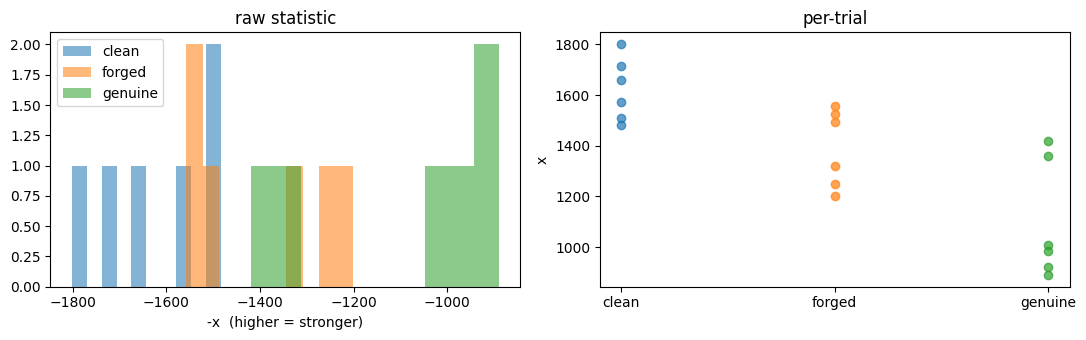

GATE 4: PASS


In [13]:
import matplotlib.pyplot as plt

def auc(pos, neg):
    # plain rank AUC, ties count half. n is tiny so no need for sklearn here
    pos, neg = np.asarray(pos), np.asarray(neg)
    return float(((pos[:, None] > neg[None, :]).sum()
                  + 0.5 * (pos[:, None] == neg[None, :]).sum()) / (len(pos) * len(neg)))

null = df[df.hypothesis == "clean"]["evidence"]
aucs = {h: auc(df[df.hypothesis == h]["evidence"], null) for h in ("genuine", "forged")}
print("AUC vs clean:", {k: round(v, 4) for k, v in aucs.items()})

print("\nvs paper Table 4:")
for h in ("genuine", "clean", "forged"):
    sub = df[df.hypothesis == h]
    print(f"  {h:<8} det {sub['detected'].mean():.2f} (exp {EXPECTED[h]['det']:.2f})  "
          f"p_mean {sub['p_value'].mean():.2e} (exp {EXPECTED[h]['p']:.2e})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for h, sub in df.groupby("hypothesis"):
    ax[0].hist(sub["evidence"], bins=10, alpha=.55, label=h)
ax[0].set_xlabel("-x  (higher = stronger)")
ax[0].legend()
ax[0].set_title("raw statistic")

for i, h in enumerate(["clean", "forged", "genuine"]):
    s = df[df.hypothesis == h]
    ax[1].scatter([i] * len(s), s["x"], alpha=.7)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(["clean", "forged", "genuine"])
ax[1].set_ylabel("x")
ax[1].set_title("per-trial")
plt.tight_layout()
plt.savefig(OUT_DIR / "gate4_separation.png", dpi=130)
plt.show()

gate4 = {"auc": aucs, "pass": bool(all(v > 0.5 for v in aucs.values()))}
(OUT_DIR / "gate4.json").write_text(json.dumps(gate4, indent=2))
print(f"GATE 4: {'PASS' if gate4['pass'] else 'FAIL'}")

## 6. Verdict

In [14]:
verdict = {
    "G1_vram": {"pass": g1["pass"], "attacker_gb": a, "target_fp16_gb": t,
                "target_fp32_gb": t32},
    "G2_timings": {r["tag"]: r["seconds"] for r in timings},
    "G3_uncensored": gate3,
    "G4_separation": gate4,
    "precision_probe": diag,
    "env": {k: META[k] for k in ("repo_commit", "lock_sha256", "dtype_target",
                                 "dtype_attacker", "n_gpu")},
}
(OUT_DIR / "phase0_verdict.json").write_text(json.dumps(verdict, indent=2))
print(json.dumps(verdict, indent=2))
print(subprocess.getoutput(f"ls -lh {OUT_DIR}"))

{
  "G1_vram": {
    "pass": true,
    "attacker_gb": 5.57,
    "target_fp16_gb": 7.36,
    "target_fp32_gb": 13.68
  },
  "G2_timings": {
    "reprompt": 332.0
  },
  "G3_uncensored": {
    "n": 18,
    "x_unique": 18,
    "x_min": 889.1171264648438,
    "x_max": 1802.162109375,
    "p_unique": 18,
    "p_zero_frac": 0.0,
    "p_min_nonzero": 5.45067676949305e-49,
    "crosscheck_max_diff": 0.0,
    "pass": true
  },
  "G4_separation": {
    "auc": {
      "genuine": 1.0,
      "forged": 0.8611111111111112
    },
    "pass": true
  },
  "precision_probe": {
    "vae fp16": {
      "nan_vae": false,
      "nan_unet": false,
      "p_value": 1.6647911409451942e-36
    },
    "vae fp32": {
      "nan_vae": false,
      "nan_unet": false,
      "p_value": 1.6647911409451942e-36
    }
  },
  "env": {
    "repo_commit": "7f9e7adde758b8451e42925544a48cc242a2cade",
    "lock_sha256": "5592c7861dbac391b2a68215b751e2a54591739cf27f962cd4f90a161ffbc497",
    "dtype_target": "torch.float16",
    "

## 7. Post-hoc statistical analysis (stat_analysis.py)

Gates 3/4 above report point-estimate AUCs from six trials per arm. A single number can
look more conclusive than it is at n = 6, so this section quantifies the uncertainty: a
95% bootstrap interval on the AUC, Mann-Whitney U tests, pooled Cohen's d, Wilson
intervals on the detection proportions, and a look at the one forgery the detector
missed. Same eighteen observations, only the transformation differs. Reproduces the
numbers quoted in the paper's "Hypothesis tests" paragraph, from phase0_scores.csv.


In [15]:
scores = pd.read_csv(OUT_DIR / "phase0_scores.csv")
scores["neg_x"] = -scores["x"]          # lower x = stronger evidence, so flip it
scores["lam_x"] = scores["lambd"] - scores["x"]

def bootstrap_auc(pos, neg, n_boot=5000, seed=42):
    # percentile CI over resamples, no distributional assumption (n is 6 per arm)
    rng = np.random.default_rng(seed)
    pos, neg = np.asarray(pos), np.asarray(neg)
    def _auc(p, n):
        return float(((p[:, None] > n[None, :]).sum() +
                      0.5 * (p[:, None] == n[None, :]).sum()) / (len(p) * len(n)))
    point = _auc(pos, neg)
    boots = np.array([_auc(rng.choice(pos, len(pos), True),
                           rng.choice(neg, len(neg), True)) for _ in range(n_boot)])
    return point, *np.percentile(boots, [2.5, 97.5])

def wilson_ci(k, n, z=1.96):
    phat, denom = k / n, 1 + z**2 / n
    centre = (phat + z**2 / (2*n)) / denom
    margin = z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n) / denom
    return centre - margin, centre + margin

def cohens_d(a, b):
    # pooled SD, positive means a > b
    a, b = np.asarray(a, float), np.asarray(b, float)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp

gen, clean, forged = (scores[scores.hypothesis == h] for h in
                      ("genuine", "clean", "forged"))

print("Detection proportions (Wilson 95% CI)")
for name, sub in (("genuine", gen), ("clean", clean), ("forged", forged)):
    k, n = sub["detected"].sum(), len(sub)
    lo, hi = wilson_ci(k, n)
    print(f"  {name.lower():<9} {k}/{n} = {k/n:.4f}   CI [{lo:.4f}, {hi:.4f}]")

print("\nBootstrap AUC (vs clean), 5000 resamples, 95% CI")
for tag, arm in (("forged", forged), ("genuine", gen)):
    for sname, col in (("-x", "neg_x"), ("lambda-x", "lam_x")):
        pt, lo, hi = bootstrap_auc(arm[col], clean[col])
        print(f"  {tag:<7} on {sname:<10} AUC = {pt:.4f}   CI [{lo:.4f}, {hi:.4f}]")


Detection proportions (Wilson 95% CI)
  genuine   6/6 = 1.0000   CI [0.6097, 1.0000]
  clean     0/6 = 0.0000   CI [0.0000, 0.3903]
  forged    5/6 = 0.8333   CI [0.4365, 0.9699]

Bootstrap AUC (vs clean), 5000 resamples, 95% CI
  forged  on -x         AUC = 0.8611   CI [0.5833, 1.0000]
  forged  on lambda-x   AUC = 0.9722   CI [0.8333, 1.0000]
  genuine on -x         AUC = 1.0000   CI [1.0000, 1.0000]
  genuine on lambda-x   AUC = 1.0000   CI [1.0000, 1.0000]


In [16]:
print("Mann-Whitney U tests (two-sided) and Cohen's d, on -x")
for n1, s1, n2, s2 in (("genuine", gen, "clean", clean),
                       ("genuine", gen, "forged", forged),
                       ("forged", forged, "clean", clean)):
    u, p = scipy.stats.mannwhitneyu(s1["neg_x"], s2["neg_x"], alternative="two-sided")
    d = cohens_d(s1["neg_x"], s2["neg_x"])
    print(f"  {n1} vs {n2}:  U = {u:.1f},  p = {p:.4e},  d = {d:.3f}")

print("\nPer-arm descriptive statistics")
for name, sub in (("genuine", gen), ("clean", clean), ("forged", forged)):
    print(f"  {name.lower():<8} mean x {sub['x'].mean():8.1f}  "
          f"median x {sub['x'].median():8.1f}  sd x {sub['x'].std():8.2f}  "
          f"mean p {sub['p_value'].mean():.2e}")

missed = forged[~forged["detected"]]
if len(missed):
    print("\nMissed forgery (inside clean range)")
    lo, hi = clean["x"].min(), clean["x"].max()
    for _, r in missed.iterrows():
        x_in_clean = (r["x"] - lo) / (hi - lo) * 100
        print(f"  trial {int(r['trial'])}: x = {r['x']:.1f}, p = {r['p_value']:.3e}")
        print(f"  clean range [{lo:.1f}, {hi:.1f}] (x sits {x_in_clean:.1f}% along it)")


Mann-Whitney U tests (two-sided) and Cohen's d, on -x
  genuine vs clean:  U = 36.0,  p = 2.1645e-03,  d = 2.840
  genuine vs forged:  U = 30.0,  p = 6.4935e-02,  d = 1.504
  forged vs clean:  U = 31.0,  p = 4.1126e-02,  d = 1.670

Per-arm descriptive statistics
  genuine  mean x   1096.5  median x    994.6  sd x   231.25  mean p 7.96e-24
  clean    mean x   1623.9  median x   1616.6  sd x   124.44  mean p 4.80e-01
  forged   mean x   1391.2  median x   1406.2  sd x   152.77  mean p 1.50e-02

Missed forgery (inside clean range)
  trial 4: x = 1558.3, p = 9.008e-02
  clean range [1483.7, 1802.2] (x sits 23.4% along it)


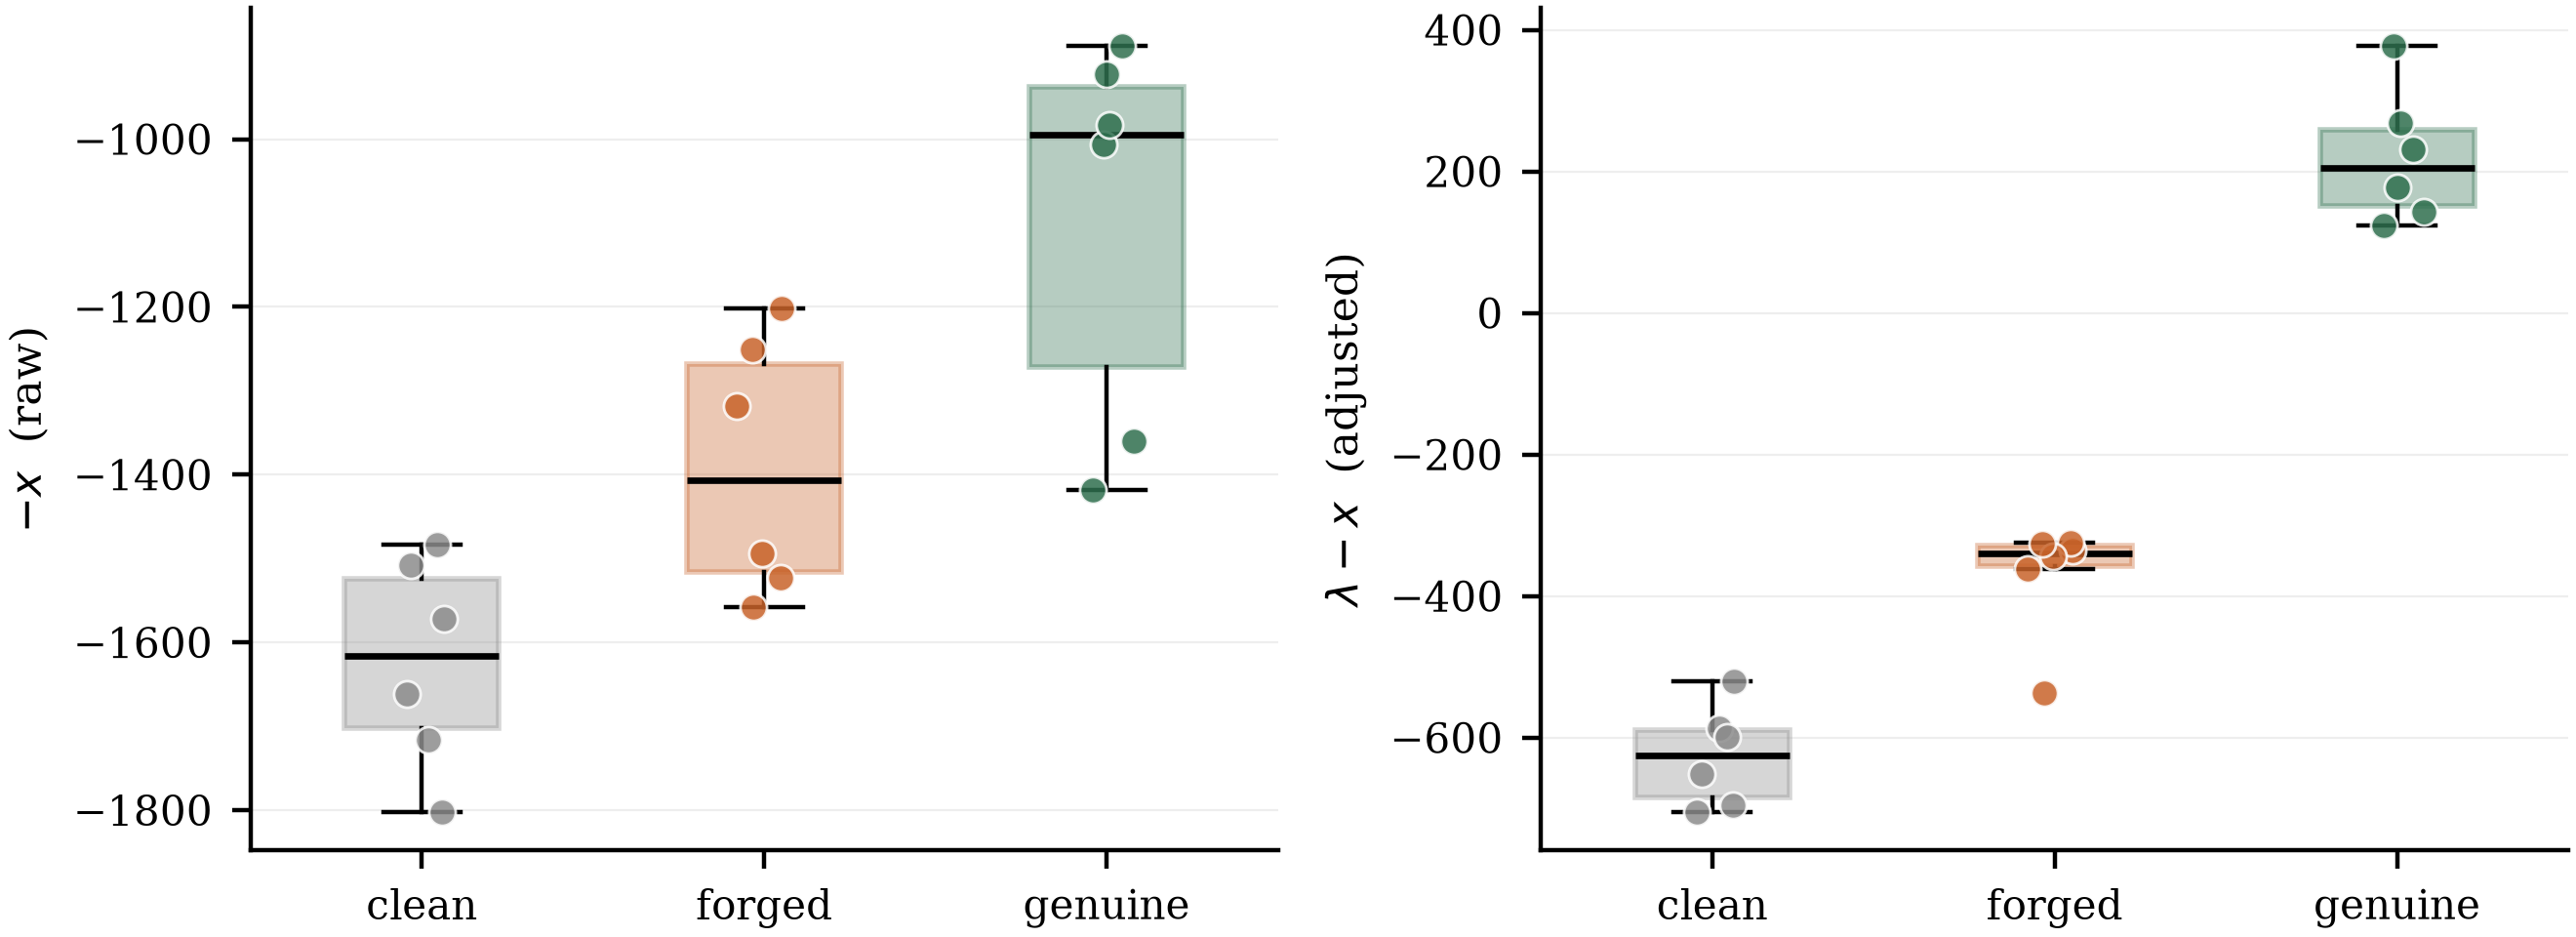

In [17]:
# Figure 6 in the paper: box + strip per arm, both candidate scores
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8.5, "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 400, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
COL = {"clean": "#8c8c8c", "forged": "#c8632a", "genuine": "#2f6f4e"}
ORD = ["clean", "forged", "genuine"]

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6))
for ax, col, label in zip(axes, ["neg_x", "lam_x"],
                          [r"$-x$  (raw)", r"$\lambda - x$  (adjusted)"]):
    data = [scores[scores.hypothesis == h][col].values for h in ORD]
    bp = ax.boxplot(data, widths=0.45, patch_artist=True,
                    medianprops=dict(color="black", lw=1.2),
                    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                    flierprops=dict(marker="none"))
    for patch, h in zip(bp["boxes"], ORD):
        patch.set_facecolor(COL[h]); patch.set_alpha(0.35); patch.set_edgecolor(COL[h])
    rng = np.random.default_rng(7)   # fixed jitter seed so the figure is reproducible
    for i, h in enumerate(ORD):
        vals = scores[scores.hypothesis == h][col].values
        jit = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jit, vals, s=24, color=COL[h],
                   alpha=0.85, zorder=3, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(1, 4)); ax.set_xticklabels(ORD)
    ax.set_ylabel(label); ax.grid(axis="y", lw=0.4, color="#eee", zorder=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig6_distributions.png", dpi=400)
plt.show()
